=== ตารางเปรียบเทียบผลลัพธ์ ===
               Model  Accuracy (%)  F1-Score
       Random Forest     99.545455  0.995452
         Naive Bayes     99.545455  0.995443
MLP / Neural Network     99.090909  0.990895
                 SVM     98.409091  0.984038
                 KNN     97.954545  0.979283
       Decision Tree     96.363636  0.963896


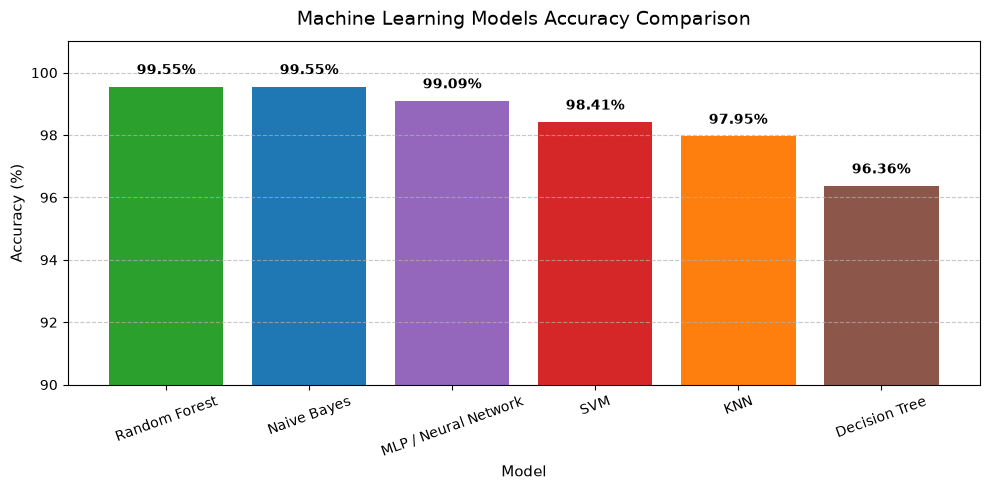

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score

# 1. เตรียมข้อมูล
df = pd.read_csv('crop_fertilizer_recommendation_dataset.csv')
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
target = 'label'

X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. รายชื่อโมเดลทั้งหมด
models = {
    "Decision Tree": DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "Naive Bayes": GaussianNB(),
    "SVM": make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, random_state=42)),
    "MLP / Neural Network": make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', max_iter=500, random_state=42))
}

# 3. เทรนและเก็บคะแนน
results = []
for name, clf in models.items():
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    results.append({
        'Model': name,
        'Accuracy (%)': accuracy_score(y_test, preds) * 100,
        'F1-Score': f1_score(y_test, preds, average='weighted')
    })

comparison_df = pd.DataFrame(results).sort_values(by='Accuracy (%)', ascending=False)
print("=== ตารางเปรียบเทียบผลลัพธ์ ===")
print(comparison_df.to_string(index=False))

# 4. พล็อตกราฟเปรียบเทียบ
plt.figure(figsize=(10, 5))
bars = plt.bar(comparison_df['Model'], comparison_df['Accuracy (%)'], color=['#2ca02c', '#1f77b4', '#9467bd', '#d62728', '#ff7f0e', '#8c564b'])
plt.ylim(90, 101)
plt.title('Machine Learning Models Accuracy Comparison', fontsize=14, pad=12)
plt.xlabel('Model', fontsize=11)
plt.ylabel('Accuracy (%)', fontsize=11)
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.3, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()